In [1]:
%matplotlib widget
import torch
import os
import copy
if torch.cuda.is_available():
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

import matplotlib.pyplot as plt

from diffSPH.operations import sph_operation, mod
from diffSPH.sampling import buildDomainDescription, sampleRegularParticles
from diffSPH.modules.eos import idealGasEOS
from diffSPH.modules.timestep import computeTimestep
from diffSPH.schema import getSimulationScheme
from diffSPH.reference.sod import buildSod_reference, sodInitialState, generateSod1D
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH
from diffSPH.reference.sod import plotSod
# from diffSPH.reference.linear import buildLinearWaveSimulation, runLinearWaveTest
from diffSPH.enums import *
from diffSPH.reference.sod import plotSod

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# device = torch.device('cpu')
dtype = torch.float32

nx = 200
dim = 2
kernel = KernelType.B7
targetNeighbors = n_h_to_nH(4, dim)
CFL = 0.3
goalRadius = 0.8

nx = 256
rho0 = 1
E0 = 1
gamma = 5/3

scheme = SimulationScheme.CRKSPH
integrationScheme = IntegrationSchemeType.rungeKutta2
viscositySwitch = ViscositySwitch.NoneSwitch
supportScheme = AdaptiveSupportScheme.NoScheme

domain = buildDomainDescription(l = 1, dim = dim, periodic = True, device = device, dtype = dtype)
domain.min = torch.tensor([-1, -1], device = device, dtype = dtype)
domain.max = torch.tensor([1, 1], device = device, dtype = dtype)

simulator, SimulationSystem, solverConfig, integrator = getSimulationScheme(
     scheme, kernel, integrationScheme, 
     gamma, targetNeighbors, domain, 
     viscositySwitch=viscositySwitch, supportScheme = supportScheme)

In [3]:
particles_l = sampleRegularParticles(nx, domain, targetNeighbors, jitter = 0.0)
particles_l2 = sampleRegularParticles(nx*2, domain, targetNeighbors, jitter = 0.0)
particles_l3 = sampleRegularParticles(nx*3, domain, targetNeighbors, jitter = 0.0)

In [4]:
def plotDomain(axis, domain):
    axis.set_xlim(domain.min[0].cpu(), domain.max[0].cpu())
    axis.set_ylim(domain.min[1].cpu(), domain.max[1].cpu())
    axis.set_aspect('equal')

    axis.plot([domain.min[0].cpu(), domain.max[0].cpu()], [domain.min[1].cpu(), domain.min[1].cpu()], 'k-')
    axis.plot([domain.min[0].cpu(), domain.max[0].cpu()], [domain.max[1].cpu(), domain.max[1].cpu()], 'k-')
    axis.plot([domain.min[0].cpu(), domain.min[0].cpu()], [domain.min[1].cpu(), domain.max[1].cpu()], 'k-')
    axis.plot([domain.max[0].cpu(), domain.max[0].cpu()], [domain.min[1].cpu(), domain.max[1].cpu()], 'k-')

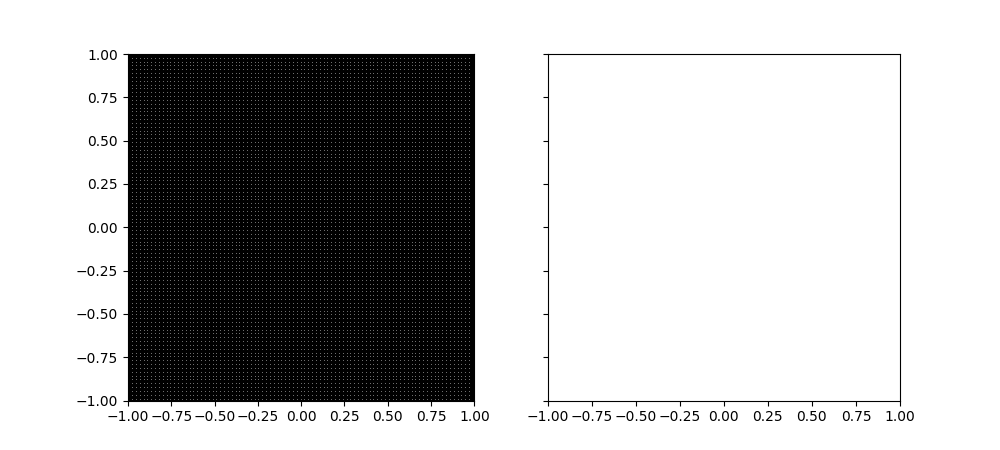

In [5]:
fig, axis = plt.subplots(1, 2, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

# axis[0,0].scatter(particles_l2.positions[:, 0].cpu(), particles_l2.positions[:, 1].cpu(), s = 1, c = 'r', marker = '.')
# axis[0,0].scatter(particles_l3.positions[:, 0].cpu(), particles_l3.positions[:, 1].cpu(), s = 1, c = 'b', marker = '.')
axis[0,0].scatter(particles_l.positions[:, 0].cpu(), particles_l.positions[:, 1].cpu(), s = 1, c = 'k', marker = 'x')

plotDomain(axis[0,0], domain)




In [6]:
def splitDomain(split_x, split_y, domain, nx):
    lx = domain.max[0] - domain.min[0]
    dx = lx / nx
    ly = domain.max[1] - domain.min[1]
    dy = ly / nx

    splitx_ = (split_x - domain.min[0]) / dx
    splity_ = (split_y - domain.min[1]) / dy

    rounded_splitx_ = torch.round(splitx_).long()
    rounded_splity_ = torch.round(splity_).long()

    splitx = rounded_splitx_ * dx + domain.min[0]
    splity = rounded_splity_ * dy + domain.min[1]

    return splitx.cpu().item(), splity.cpu().item()

In [7]:
splitDomain(0.2, 0.5, domain, nx)

def maskParticles(particles, split_x, split_y, domain, nx):
    if isinstance(split_x, list):
        splitXLower, splitYLower = splitDomain(split_x[0], split_y[0], domain, nx)
        splitXUpper, splitYUpper = splitDomain(split_x[1], split_y[1], domain, nx)

        A_1 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] < splitYLower)
        A_2 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] < splitYLower)
        A_3 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] >= splitYUpper)
        A_4 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] >= splitYUpper)
        maskA = torch.logical_or(torch.logical_or(A_1, A_2), torch.logical_or(A_3, A_4))

        B_1 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] >= splitYLower)
        B_2 = (particles.positions[:, 0] < splitXLower) & (particles.positions[:, 1] < splitYUpper)
        B_3 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] >= splitYLower)
        B_4 = (particles.positions[:, 0] >= splitXUpper) & (particles.positions[:, 1] < splitYUpper)
        maskB = torch.logical_or(torch.logical_and(B_1, B_2), torch.logical_and(B_3, B_4))

        C_1 = (particles.positions[:, 0] >= splitXLower) & (particles.positions[:, 1] < splitYLower)
        C_2 = (particles.positions[:, 0] < splitXUpper) & (particles.positions[:, 1] < splitYLower)
        C_3 = (particles.positions[:, 0] >= splitXLower) & (particles.positions[:, 1] >= splitYUpper)
        C_4 = (particles.positions[:, 0] < splitXUpper) & (particles.positions[:, 1] >= splitYUpper)
        maskC = torch.logical_or(torch.logical_and(C_1, C_2), torch.logical_and(C_3, C_4))

        mask = torch.ones_like(particles.positions[:, 0], dtype=torch.int64, device=device)*3
        mask[maskA] = 0
        mask[maskB] = 2
        mask[maskC] = 1

        return mask, [splitXLower, splitXUpper], [splitYLower, splitYUpper]

    else:

        splitx, splity = splitDomain(split_x, split_y, domain, nx)

        maskA = (particles.positions[:, 0] < splitx) & (particles.positions[:, 1] < splity)
        maskB = (particles.positions[:, 0] >= splitx) & (particles.positions[:, 1] < splity)
        maskC = (particles.positions[:, 0] < splitx) & (particles.positions[:, 1] >= splity)
        maskD = (particles.positions[:, 0] >= splitx) & (particles.positions[:, 1] >= splity)

        mask = torch.zeros_like(particles.positions[:, 0], dtype=torch.int64, device=device)
        mask[maskA] = 0
        mask[maskB] = 1
        mask[maskC] = 2
        mask[maskD] = 3

        return mask, splitx, splity

def maskParticlesSymmetric(particles, split_x, split_y, domain, nx):
    return maskParticles(particles, [split_x, domain.max[0] - split_x], [split_y, domain.max[1] - split_y], domain, nx)


tensor(53248, device='cuda:0')


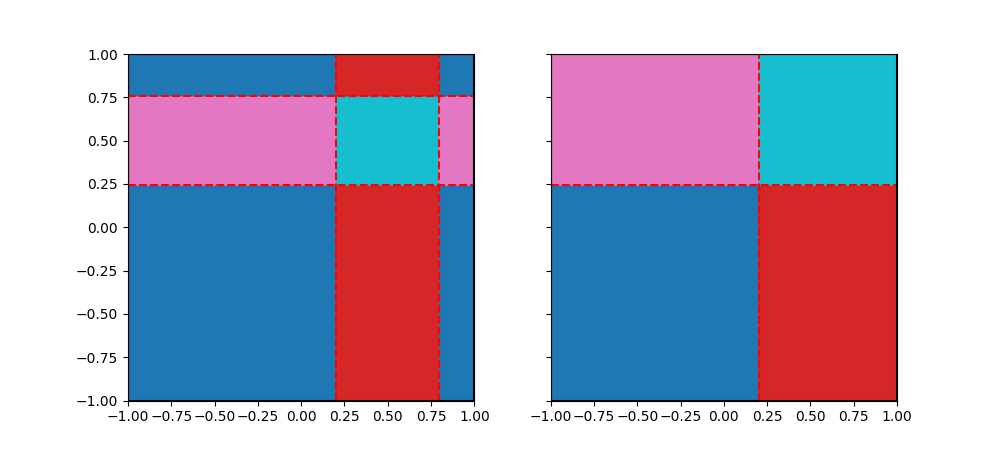

In [8]:
splitLineX = 0.2
splitLineY = 0.24
splitX, splitY = splitDomain(splitLineX, splitLineY, domain, nx)
mask, *_ = maskParticlesSymmetric(particles_l, splitX, splitY, domain, nx)
maskHalf, *_ = maskParticles(particles_l, splitX, splitY, domain, nx)
print(torch.sum(mask))

fig, axis = plt.subplots(1, 2, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

axis[0,0].scatter(particles_l.positions[:, 0].cpu(), particles_l.positions[:, 1].cpu(), s = 4, c = mask.cpu(), marker = '.', cmap = 'tab10')
# axis[0,0].scatter(particles_l3.positions[:, 0].cpu(), particles_l3.positions[:, 1].cpu(), s = 1, c = 'b', marker = '.')
# axis[0,0].scatter(particles_l.positions[:, 0].cpu(), particles_l.positions[:, 1].cpu(), s = 4, c = 'k', marker = 'x')

axis[0,0].axvline(splitX, color='r', linestyle='--')
axis[0,0].axhline(splitY, color='r', linestyle='--')
axis[0,0].axvline(domain.max[0].cpu() - splitX, color='r', linestyle='--')
axis[0,0].axhline(domain.max[1].cpu() - splitY, color='r', linestyle='--')

axis[0,1].scatter(particles_l.positions[:, 0].cpu(), particles_l.positions[:, 1].cpu(), s = 4, c = maskHalf.cpu(), marker = '.', cmap = 'tab10')
axis[0,1].axvline(splitX, color='r', linestyle='--')
axis[0,1].axhline(splitY, color='r', linestyle='--')



plotDomain(axis[0,0], domain)
plotDomain(axis[0,1], domain)

Sampling regions with nx = [256, 256, 256, 256], splitX = [-0.8571428571428572, 0.8571428571428572], splitY = [-0.5, 0.5], jitter = 0.0


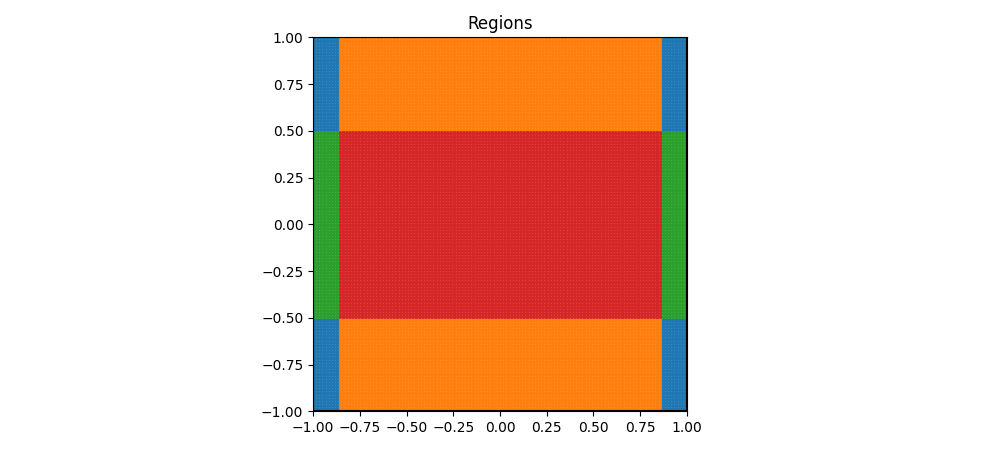

In [9]:
from diffSPH.util import ParticleSet 
import numpy as np

def sampleRegions(domain, nx, targetNeighbors, splitX, splitY, jitter = 0.0):
    print(f'Sampling regions with nx = {nx}, splitX = {splitX}, splitY = {splitY}, jitter = {jitter}')
    if isinstance(nx, int):
        particles = sampleRegularParticles(nx, domain, targetNeighbors, jitter = jitter)

        # split_x, split_y = splitDomain(splitX, splitY, domain, nx)
        mask, split_x, split_y = maskParticles(particles, splitX, splitY, domain, nx)

        particlesA = ParticleSet(
            positions = particles.positions[mask == 0],
            supports = particles.supports[mask == 0],
            masses = particles.masses[mask == 0],
            densities = particles.densities[mask == 0]
        ) 
        particlesB = ParticleSet(
            positions = particles.positions[mask == 1],
            supports = particles.supports[mask == 1],
            masses = particles.masses[mask == 1],
            densities = particles.densities[mask == 1]
        ) 
        particlesC = ParticleSet(
            positions = particles.positions[mask == 2],
            supports = particles.supports[mask == 2],
            masses = particles.masses[mask == 2],
            densities = particles.densities[mask == 2]
        ) 
        particlesD = ParticleSet(
            positions = particles.positions[mask == 3],
            supports = particles.supports[mask == 3],
            masses = particles.masses[mask == 3],
            densities = particles.densities[mask == 3]
        )

        return particlesA, particlesB, particlesC, particlesD, split_x, split_y
    else:
        particlesA = sampleRegularParticles(nx[0], domain, targetNeighbors, jitter = jitter)
        particlesB = sampleRegularParticles(nx[1], domain, targetNeighbors, jitter = jitter)
        particlesC = sampleRegularParticles(nx[2], domain, targetNeighbors, jitter = jitter)
        particlesD = sampleRegularParticles(nx[3], domain, targetNeighbors, jitter = jitter)

        # splitx, splity = splitDomain(splitX, splitY, domain, np.min(nx))

        maskA, splitx, splity = maskParticles(particlesA, splitX, splitY, domain, np.min(nx))
        maskB, *_ = maskParticles(particlesB, splitX, splitY, domain, np.min(nx))
        maskC, *_ = maskParticles(particlesC, splitX, splitY, domain, np.min(nx))
        maskD, *_ = maskParticles(particlesD, splitX, splitY, domain, np.min(nx))

        particlesA = ParticleSet(
            positions = particlesA.positions[maskA == 0],
            supports = particlesA.supports[maskA == 0],
            masses = particlesA.masses[maskA == 0],
            densities = particlesA.densities[maskA == 0]
        ) 
        particlesB = ParticleSet(
            positions = particlesB.positions[maskB == 1],
            supports = particlesB.supports[maskB == 1],
            masses = particlesB.masses[maskB == 1],
            densities = particlesB.densities[maskB == 1]
        ) 
        particlesC = ParticleSet(
            positions = particlesC.positions[maskC == 2],
            supports = particlesC.supports[maskC == 2],
            masses = particlesC.masses[maskC == 2],
            densities = particlesC.densities[maskC == 2]
        )
        particlesD = ParticleSet(
            positions = particlesD.positions[maskD == 3],
            supports = particlesD.supports[maskD == 3],
            masses = particlesD.masses[maskD == 3],
            densities = particlesD.densities[maskD == 3]
        )

        return particlesA, particlesB, particlesC, particlesD, splitx, splity
    
def sampleRegionsSymmetric(domain, nx, targetNeighbors, splitX, splitY, jitter = 0.0):
    lx = domain.max[0].item() - domain.min[0].item()
    ly = domain.max[1].item() - domain.min[1].item()

    minX = domain.min[0].item()
    minY = domain.min[1].item()
    maxX = domain.max[0].item()
    maxY = domain.max[1].item()

    splitXUpper = minX + (maxX - minX) * (1 - (splitX - minX) / (maxX - minX))
    splitYUpper = minY + (maxY - minY) * (1 - (splitY - minY) / (maxY - minY))

    return sampleRegions(domain, nx, targetNeighbors, [splitX, splitXUpper], [splitY, splitYUpper], jitter = jitter)

splitLineX = -1+1/7
splitLineY = -1/2

particlesA, particlesB, particlesC, particlesD, splitx, splity = sampleRegionsSymmetric(domain, [nx, nx, nx, nx], targetNeighbors, splitLineX, splitLineY)

fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

axis[0,0].scatter(particlesA.positions[:, 0].cpu(), particlesA.positions[:, 1].cpu(), s = 4, marker = '.')
axis[0,0].scatter(particlesB.positions[:, 0].cpu(), particlesB.positions[:, 1].cpu(), s = 4, marker = '.')
axis[0,0].scatter(particlesC.positions[:, 0].cpu(), particlesC.positions[:, 1].cpu(), s = 4, marker = '.')
axis[0,0].scatter(particlesD.positions[:, 0].cpu(), particlesD.positions[:, 1].cpu(), s = 4, marker = '.')

axis[0,0].set_title('Regions')

plotDomain(axis[0,0], domain)

fig.tight_layout()

In [10]:

# initialStateLeft = sodInitialState(1, 1, 0)
# initialStateRight = sodInitialState(0.1795, 0.25, 0)

In [11]:
# particlesD = particlesD._replace(masses = particlesB.masses * 2.0)

ParticleSet(positions=tensor([[-0.9961, -0.9961],
        [-0.9961, -0.9883],
        [-0.9961, -0.9805],
        ...,
        [ 0.8555,  0.4805],
        [ 0.8555,  0.4883],
        [ 0.8555,  0.4961]], device='cuda:0'), supports=tensor([0.0312, 0.0312, 0.0312,  ..., 0.0312, 0.0312, 0.0312], device='cuda:0'), masses=tensor([6.1035e-05, 6.1035e-05, 6.1035e-05,  ..., 6.1035e-05, 6.1035e-05,
        6.1035e-05], device='cuda:0'), densities=tensor([1., 1., 1.,  ..., 1., 1., 1.], device='cuda:0'))


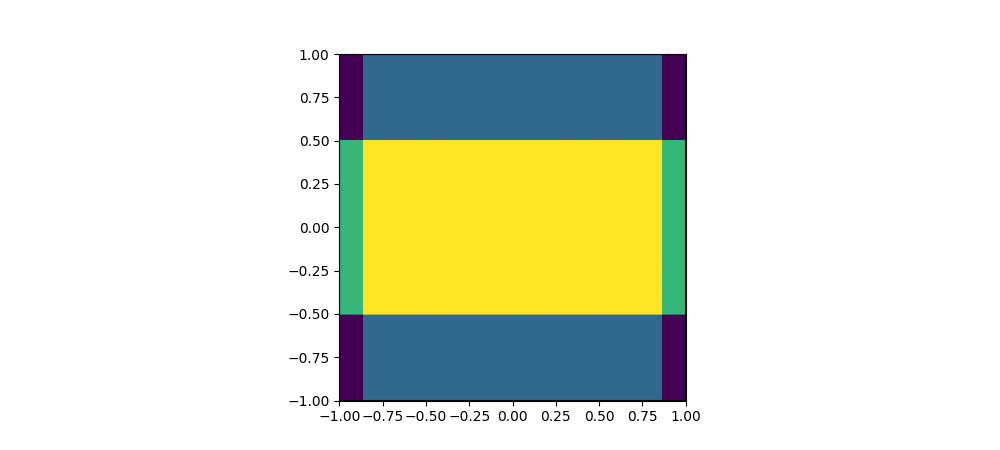

In [12]:
def mergeParticles(particles_list):
    positions = torch.cat([p.positions for p in particles_list], dim=0)
    supports = torch.cat([p.supports for p in particles_list], dim=0)
    masses = torch.cat([p.masses for p in particles_list], dim=0)
    densities = torch.cat([p.densities for p in particles_list], dim=0)
    index = torch.cat([torch.ones_like(p.masses) * i for i, p in enumerate(particles_list)], dim=0)

    return ParticleSet(
        positions = positions,
        supports = supports,
        masses = masses,
        densities = densities
    ), index

particles, setIndex = mergeParticles([particlesA, particlesB, particlesC, particlesD])

print(particles)

fig, axis = plt.subplots(1, 1, figsize=(10, 4.5), squeeze=False, sharex=True, sharey=True)

axis[0,0].scatter(particles.positions[:, 0].cpu(), particles.positions[:, 1].cpu(), s = 4, marker = '.', c = setIndex.cpu())

plotDomain(axis[0,0], domain)

In [13]:
from diffSPH.schemes.states.compressiblesph import CompressibleState

Pinitial = torch.ones_like(particles.positions[:, 0], device=device, dtype=dtype) * 1.0
rho = torch.ones_like(particles.positions[:, 0], device=device, dtype=dtype) * rho0

masses = particles.masses.clone()
m0 = torch.sum(masses) / particles.positions.shape[0]

Pinitial[setIndex == 0] = 1.0
masses[setIndex == 0] = m0
rho[setIndex == 0] = rho0

Pinitial[setIndex == 1] = 0.1
masses[setIndex == 1] = 0.1 * m0
rho[setIndex == 1] = 0.1 * rho0

Pinitial[setIndex == 2] = 1.0
masses[setIndex == 2] =  m0
rho[setIndex == 2] = rho0

Pinitial[setIndex == 3] = 0.1
masses[setIndex == 3] = m0
rho[setIndex == 3] = rho0


# Pinitial[setIndex == 3] = 0.1795
# rho[setIndex == 3] = 0.25
# particles = particles._replace(masses = torch.where(setIndex == 3, particles.masses / 4.0, particles.masses))

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = rho, gamma = gamma)
# v_initial = torch.zeros_like(particles_l.positions)


simulationState = CompressibleState(
    positions = particles.positions,
    supports = particles.supports,
    masses = masses,
    densities = rho,        
    velocities = torch.zeros_like(particles.positions, device = device, dtype = dtype),
    
    kinds = torch.zeros_like(particles.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles.positions.shape[0], device = device, dtype = torch.int32),

    internalEnergies = u_,
    totalEnergies = None,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(rho),
    alpha0s = torch.ones_like(rho)
)

# simulationState.velocities[setIndex == 3,0] = 1

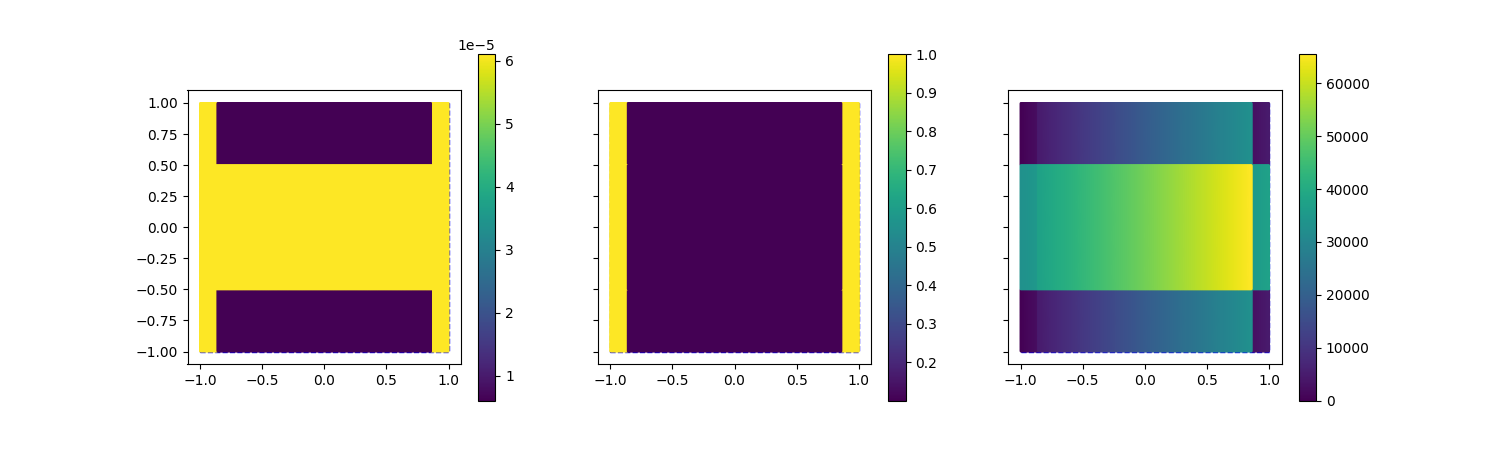

In [14]:
fig, axis = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False, sharex=True, sharey=True)

from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen
markerSize = 1.0

_ = visualizeParticles(fig, axis[0,0], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.x', gridVisualization = False, quantity = simulationState.masses, markerSize=markerSize)
_ = visualizeParticles(fig, axis[0,1], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.x', gridVisualization = False, quantity = Pinitial, markerSize=markerSize)
_ = visualizeParticles(fig, axis[0,2], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.x', gridVisualization = False, quantity = simulationState.UIDs, markerSize=markerSize)

<function generateNoiseInterpolator.<locals>.<lambda> at 0x7f97b086ab60>


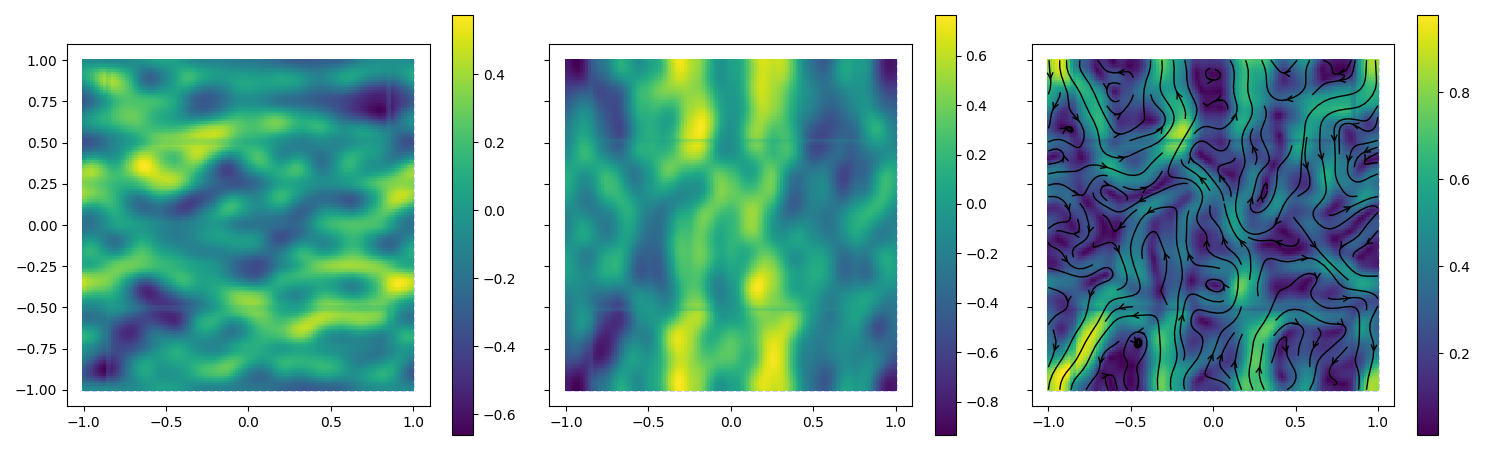

In [15]:
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen
from diffSPH.sampling import generateNoiseInterpolator, sampleDivergenceFreeNoise

octaves = 4
lacunarity = 2
persistence = 0.5
baseFrequency = 1
tileable = True
kind = 'perlin'
seed = 4235

noiseGen = generateNoiseInterpolator(nx, nx, domain, dim = domain.dim, octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)

print(noiseGen)

velocityField = sampleDivergenceFreeNoise(simulationState, domain, solverConfig, nx, octaves, lacunarity, persistence, baseFrequency, tileable, kind, seed)
# simulationState.velocities = velocityField

fig, axis = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False, sharex=True, sharey=True)
_ = visualizeParticles(fig, axis[0,0], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.x', gridVisualization = True, quantity = velocityField[:,0])
_ = visualizeParticles(fig, axis[0,1], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = '.y', gridVisualization = True, quantity = velocityField[:,1])
_ = visualizeParticles(fig, axis[0,2], simulationState, domain, kernel = solverConfig['kernel'], cmap = 'viridis', mapping = 'L2', gridVisualization = True, quantity = velocityField, streamLines = True)

fig.tight_layout()

In [16]:
from diffSPH.modules.eos import idealGasEOS
from diffSPH.modules.compressible import CompressibleState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr



from diffSPH.neighborhood import evaluateNeighborhood, filterNeighborhoodByKind, SupportScheme
neighborhood, neighbors = evaluateNeighborhood(simulationState, domain, kernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
numNeighbors = coo_to_csr(filterNeighborhoodByKind(simulationState, neighbors.neighbors, which = 'noghost')).rowEntries
densities = computeDensity(simulationState, kernel, neighbors.get('noghost'), SupportScheme.Gather, solverConfig)
print(densities.min(), densities.max(), densities.mean())

A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = simulationState.densities, gamma = gamma)

simulationState.internalEnergies = u_


particleSystem = SimulationSystem(
        systemState = simulationState,
        domain = domain,
        neighborhoodInfo = neighborhood,
        t = 0
    )

timeLimit = 4
dt = computeTimestep(scheme, 1e-3, particleSystem.systemState, solverConfig, None)
# dt = torch.tensor(1e-4, dtype = dtype, device = device)
timesteps = int(timeLimit / dt)
actualState = copy.deepcopy(particleSystem)
print(dt, timesteps)

tensor(0.1000, device='cuda:0') tensor(1.0000, device='cuda:0') tensor(0.6133, device='cuda:0')
tensor(0.0018, device='cuda:0') 2166


In [17]:
print(particleSystem)

CompSPHSystem(domain=DomainDescription(min=tensor([-1., -1.], device='cuda:0'), max=tensor([1., 1.], device='cuda:0'), periodic=tensor([True, True], device='cuda:0'), dim=2), neighborhoodInfo=NeighborhoodInformation(points_a=PointCloud(positions=tensor([[-0.9961, -0.9961],
        [-0.9961, -0.9883],
        [-0.9961, -0.9805],
        ...,
        [ 0.8555,  0.4805],
        [ 0.8555,  0.4883],
        [ 0.8555,  0.4961]], device='cuda:0'), supports=tensor([0.0312, 0.0312, 0.0312,  ..., 0.0312, 0.0312, 0.0312], device='cuda:0')), points_b=PointCloud(positions=tensor([[-0.9961, -0.9961],
        [-0.9961, -0.9883],
        [-0.9961, -0.9805],
        ...,
        [ 0.8555,  0.4805],
        [ 0.8555,  0.4883],
        [ 0.8555,  0.4961]], device='cuda:0'), supports=tensor([0.0312, 0.0312, 0.0312,  ..., 0.0312, 0.0312, 0.0312], device='cuda:0')), domain=DomainDescription(min=tensor([-1., -1.], device='cuda:0'), max=tensor([1., 1.], device='cuda:0'), periodic=tensor([True, True], device=

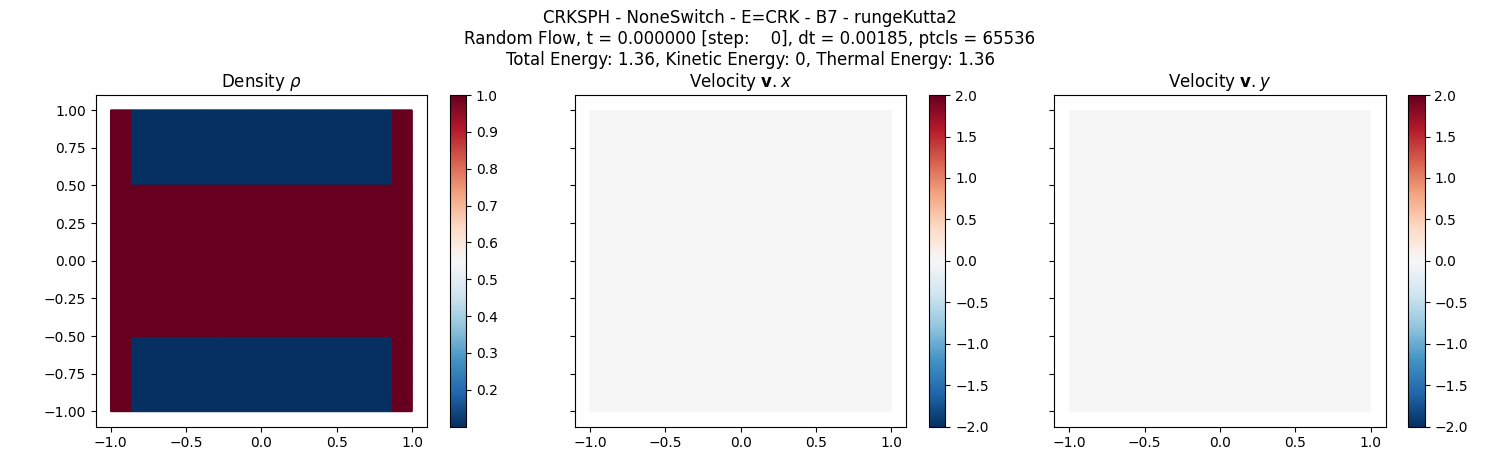

In [18]:
from diffSPH.plotting import visualizeParticles, updatePlot
from diffSPH.modules.adaptiveSmoothingASPH import n_h_to_nH, evaluateOptimalSupportOwen

fluidParticles = actualState.systemState

fig, axis = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False, sharex=True, sharey=True)

s = 1
densityPlotState = visualizeParticles(fig, axis[0,0],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = fluidParticles.densities, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                    #  scaling = 'sym',
                     cmap = 'RdBu_r',
                     midPoint=1.5,
                     title='Density $\\rho$',
                     markerSize = s,
                     gridVisualization=False, gridResolution=256)

velocityXPlotState = visualizeParticles(fig, axis[0,1],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = fluidParticles.velocities, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'RdBu_r',
                     midPoint=0,
                     title='Velocity $\mathbf{v}.x$',
                     mapping = '.x',
                    #  operation = 'curl',
                     markerSize = s,
                     gridVisualization=True, gridResolution=255, vmin = -2, vmax = 2)
velocityYPlotState = visualizeParticles(fig, axis[0,2],
                     particles = fluidParticles, 
                     domain = domain, 
                     quantity = fluidParticles.velocities, 
                     which = 'fluid',
                     visualizeBoth=False,
                     kernel = solverConfig['kernel'],
                     plotDomain = False,
                     cmap = 'RdBu_r',
                     midPoint=0,
                     title='Velocity $\mathbf{v}.y$',
                     mapping = '.y',
                     markerSize = s,
                     gridVisualization=True, streamLines = False, gridResolution=255, vmin = -2, vmax = 2)

# for ax in axis.flatten():
    # ax.set_xlim(-1, 1)
    # ax.set_ylim(-1,1)
kineticEnergy = 0.5 * (torch.linalg.norm(actualState.systemState.velocities, dim = -1) **2 * actualState.systemState.masses).sum()
thermalEnergy = (actualState.systemState.internalEnergies * actualState.systemState.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy


fig.suptitle(f'{solverConfig["schemeName"]}\nRandom Flow, t = {actualState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(actualState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
# fig.suptitle(f'{solverConfig["schemeName"]}\nSedov-Taylor Explosion, t = {simulationState.t:2f} [step: {0:4d}], dt = {dt:.3g}, ptcls = {len(simulationState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')

fig.tight_layout()


In [19]:

# for patch in axis[0,2].patches[:]:
#     print(patch)
#     if isinstance(patch, mpl.patches.FancyArrowPatch):
#         patch.remove()
# for c in list(axis[0,2].collections):
#     if isinstance(c, mpl.collections.LineCollection):
#         c.remove()

In [20]:

import math
fps = 50
exportInterval = 1 / fps
exportSteps = int(math.ceil(exportInterval / dt))
newDt = exportInterval / exportSteps
plotInterval = int(math.floor(exportInterval / newDt))
plotInterval = min(max(plotInterval,1), 40)
print(f'Current dt: {dt}')
print(f'Plot Interval: {plotInterval}')
print(f'export Steps: {exportSteps}')
print(f'New dt: {newDt}')

imagePrefix = './images/2DShock2/'
os.makedirs(imagePrefix, exist_ok = True)

fig.savefig(f'{imagePrefix}frame_{0:05d}.png', dpi = 100)

Current dt: 0.0018465120811015368
Plot Interval: 11
export Steps: 11
New dt: 0.0018181818181818182


In [21]:
import matplotlib as mpl
states = []
dt = newDt
actualState.systemState.divergence = torch.zeros_like(actualState.systemState.densities)
for i in (tq:=tqdm(range(timesteps))):
# while(True):
    actualState, currentState, updates = integrator.function(actualState, dt, simulator, solverConfig, priorStep = actualState.priorStep)
    actualState.priorStep = [updates[-1], currentState[-1]]
    # if i%100 == 0:
        # states.append(copy.deepcopy(simulationState).to(dtype = torch.float32, device = 'cpu'))

    kineticEnergy = 0.5 * (torch.linalg.norm(actualState.systemState.velocities, dim = -1) **2 * actualState.systemState.masses).sum()
    thermalEnergy = (actualState.systemState.internalEnergies * actualState.systemState.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    tq.set_postfix({
        'Kinetic Energy': kineticEnergy.item(),
        'Thermal Energy': thermalEnergy.item(),
        'Total Energy': totalEnergy.item(),
        'Time': actualState.t.item() if torch.is_tensor(actualState.t) else actualState.t,
    })

    if (i % plotInterval == 0 and i > 0) or i == timesteps - 1:
        updatePlot(densityPlotState, actualState.systemState, actualState.systemState.densities)
        updatePlot(velocityXPlotState, actualState.systemState, actualState.systemState.velocities, mapping = '.x', vmin = -2, vmax = 2)
        # for patch in axis[0,2].patches[:]:
        #     print(patch)
        #     if isinstance(patch, mpl.patches.FancyArrowPatch):
        #         patch.remove()
        updatePlot(velocityYPlotState, actualState.systemState, actualState.systemState.velocities, mapping = '.y', vmin = -2, vmax = 2)

        # for ax in axis.flatten():
            # ax.set_xlim(-1, 1)
            # ax.set_ylim(-1,1)

        fig.suptitle(f'{solverConfig["schemeName"]}\nKevin Helmholtz, t = {actualState.t:2f} [step: {i:4d}], dt = {dt:.3g}, ptcls = {len(actualState.systemState.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')


        fig.canvas.draw()
        fig.canvas.flush_events()
        fig.savefig(f'{imagePrefix}frame_{i:05d}.png', dpi = 100)

  0%|          | 0/2166 [00:00<?, ?it/s]

Namespace CRKSPH not found in config. Setting eta_crit to 0.25
Key eta_fold not found in config["CRKSPH"]. Setting eta_fold to 0.2
term1: min -0.13885498046875, max 0.13710078597068787, mean 1.908326339616906e-05
term2: min -346454.21875, max 346454.25, mean -6.1599575928994454e-06
term3: min -0.10225187987089157, max 0.10193132609128952, mean 5.4757565521867946e-05
term4: min -14.882678985595703, max 14.882678985595703, mean -4.0388987293527023e-11
summed: min -346439.46875, max 346439.4375, mean 8.52468019729713e-06
gradW_ij: min -346454.09375, max 346454.09375, mean 2.7909571144846268e-05
term1: min -0.13885498046875, max 0.13710078597068787, mean 1.908326339616906e-05
term2: min -346454.21875, max 346454.25, mean -3.801073398790322e-05
term3: min -0.10225187987089157, max 0.10193132609128952, mean 5.4757565521867946e-05
term4: min -14.882678985595703, max 14.882678985595703, mean 5.410936698702073e-10
summed: min -346439.46875, max 346439.4375, mean 6.960848986636847e-05
gradW_ij: 

KeyboardInterrupt: 

In [ ]:
from diffSPH.util import postProcess

postProcess(
    imagePrefix = imagePrefix,
    fps = 50,
    exportName = 'random_flow',
    targetLongEdge = 1200
)
# def postProcess(imagePrefix, fps, exportName, targetLongEdge = 600):

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 450) to (1504, 464) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Copying video to videos folder
Done!
